In [3]:
data = pd.read_csv("/content/india_data_extracted (1).csv")
data

,Area,Year,Savanna fires,Forest fires,Crop Residues,Rice Cultivation,Drained organic soils (CO2),Pesticides Manufacturing,Food Transport,Forestland,...,Manure Management,Fires in organic soils,Fires in humid tropical forests,On-farm energy use,Rural population,Urban population,Total Population - Male,Total Population - Female,total_emission,Average Temperature °C
0,India,1990,333.7507,4560.8585,15344.5174,126167.9535,5007.9141,2401.0,9715.1767,-227396.9133,...,30870.2642,0.0,1290.5445,14986.1127,647836752.0,222296728.0,449984059.0,420468106.0,262529.4985,-0.032750
1,India,1991,333.7507,4560.8585,15312.7949,126055.9214,5007.9141,2349.0,10253.5867,-227396.9133,...,31286.5775,0.0,1290.5445,16620.0570,659127729.0,228927146.0,459463492.0,429478264.0,281816.2598,0.144667
2,India,1992,333.7507,4560.8585,15726.8022,123473.5320,5007.9141,2363.0,10120.9643,-227396.9133,...,31842.4951,0.0,1290.5445,17383.6296,670596991.0,235424115.0,469046096.0,438527953.0,292394.0153,0.055667
3,India,1993,333.7507,4560.8585,16142.4254,125731.6715,5007.9141,2204.0,10263.6540,-227396.9133,...,32013.4897,0.0,1290.5445,18883.4382,682039727.0,242018090.0,478735976.0,447615320.0,307031.9283,0.225833
4,India,1994,333.7507,4560.8585,16262.4925,126544.4835,5007.9141,2006.0,10534.4403,-227396.9133,...,32229.2937,0.0,1290.5445,20574.5957,693476126.0,248728123.0,488535405.0,456726553.0,322354.6000,0.095417
5,India,1995,333.7507,4560.8585,16358.1080,126503.1040,5023.7664,2051.0,10802.1953,-227396.9133,...,32428.6890,0.0,1290.5445,21373.6566,704923971.0,255558824.0,498432465.0,465846665.0,343444.3018,0.298917
6,India,1996,203.7261,1788.6458,16780.0658,128276.5120,5022.4718,2027.0,12702.9874,-227396.9133,...,32635.9639,0.0,978.7452,25646.5671,716378887.0,262514330.0,508349160.0,474932057.0,351910.4797,0.277917
7,India,1997,140.2193,1538.3997,17220.1388,128482.8185,5026.1344,1822.0,13956.5606,-227396.9133,...,32738.6752,0.0,720.8438,28242.9790,727825980.0,269579338.0,518303618.0,484031612.0,369439.2492,-0.048833
8,India,1998,228.6617,1561.6789,17361.5309,132421.2621,5025.4913,1797.0,13848.6247,-227396.9133,...,32828.0713,0.0,706.7553,27898.0452,739222779.0,276751263.0,528287413.0,493147162.0,395854.7030,0.633417
9,India,1999,254.2614,3236.4138,17843.7938,133478.5088,5010.6514,1795.0,14399.9548,-227396.9133,...,32914.4130,0.0,1160.2553,28459.8997,750527571.0,284011643.0,538244360.0,502255693.0,402165.4965,0.466667


Mean Squared Error: 6954033927.17829
Mean Absolute Error: 63729.722912785845
Root Mean Squared Error: 83390.85038047214
R2 Score: 0.8583480160446855


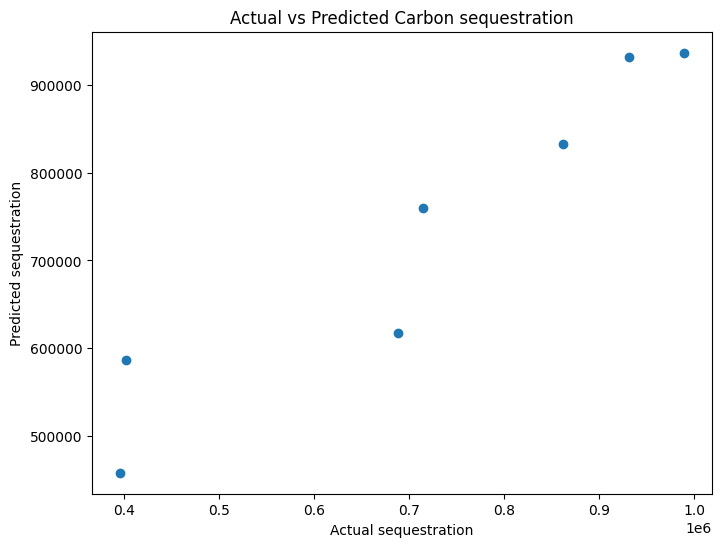

In [15]:
# RANDOM FOREST
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load dataset
data = pd.read_csv("/content/india_data_extracted (1).csv")

# Drop non-numeric column
data = data.drop(columns=["Area"])


# Define target variable (carbon sequestration )
y = data["total_emission"]

# Define input features
X = data[["Forest fires","Crop Residues","Pesticides Manufacturing"]]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest Regression Model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

# Visualization
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual sequestration")
plt.ylabel("Predicted sequestration")
plt.title("Actual vs Predicted Carbon sequestration")
plt.show()

     Area  Year  Savanna fires  Forest fires  Crop Residues  Rice Cultivation  \
0   India  1990       333.7507     4560.8585     15344.5174       126167.9535   
1   India  1991       333.7507     4560.8585     15312.7949       126055.9214   
2   India  1992       333.7507     4560.8585     15726.8022       123473.5320   
3   India  1993       333.7507     4560.8585     16142.4254       125731.6715   
4   India  1994       333.7507     4560.8585     16262.4925       126544.4835   
5   India  1995       333.7507     4560.8585     16358.1080       126503.1040   
6   India  1996       203.7261     1788.6458     16780.0658       128276.5120   
7   India  1997       140.2193     1538.3997     17220.1388       128482.8185   
8   India  1998       228.6617     1561.6789     17361.5309       132421.2621   
9   India  1999       254.2614     3236.4138     17843.7938       133478.5088   
10  India  2000       188.2463     1845.6861     17810.2655       132154.3642   
11  India  2001       172.46

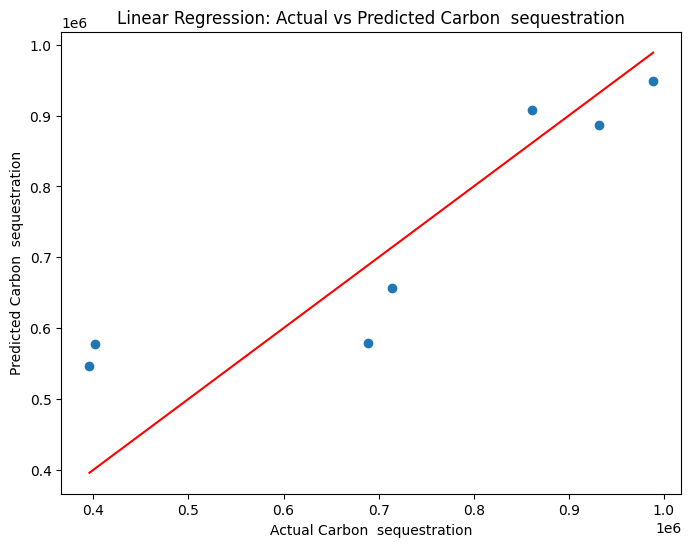

In [16]:
# linear regression
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load dataset
data = pd.read_csv("/content/india_data_extracted (1).csv")
print(data)
# Remove non-numeric column if present
data = data.drop(columns=["Area"])

# Target variable
y = data["total_emission"]

# Features
X = data[["Forest fires","Crop Residues","Pesticides Manufacturing"]]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

# Visualization
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Carbon  sequestration")
plt.ylabel("Predicted Carbon  sequestration")
plt.title("Linear Regression: Actual vs Predicted Carbon  sequestration")

plt.show()

Mean Squared Error: 16573017339.259306
Mean Absolute Error: 97272.97971428563
Root Mean Squared Error: 128736.23164928865
R2 Score: 0.6624116576341633


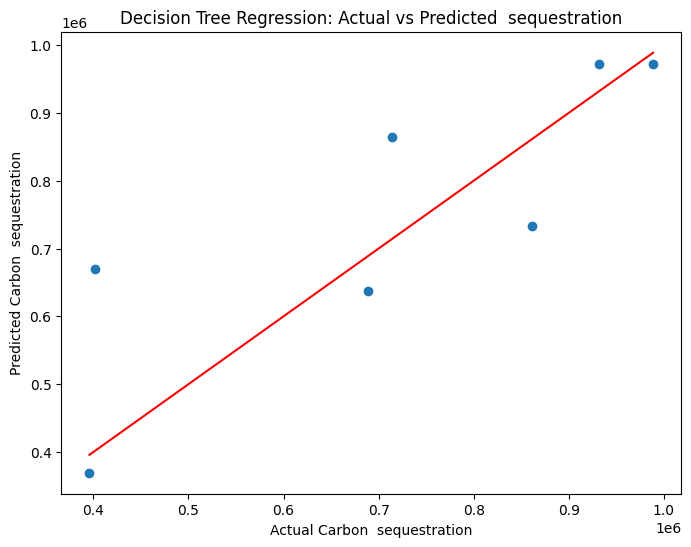

In [17]:
# DECISION TREE REGRESSION
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load dataset
data = pd.read_csv("/content/india_data_extracted (1).csv")

# Remove non-numeric column if present
data = data.drop(columns=["Area"])

# Target variable
y = data["total_emission"]

# Feature variables
X = data[["Forest fires","Crop Residues","Pesticides Manufacturing"]]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Decision Tree model
model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

# Visualization
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Carbon  sequestration")
plt.ylabel("Predicted Carbon  sequestration")
plt.title("Decision Tree Regression: Actual vs Predicted  sequestration")

plt.show()

In [11]:
# Compare Estimators
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load dataset
data = pd.read_csv("/content/india_data_extracted (1).csv")

# Remove non-numeric column if present
data = data.drop(columns=["Area"])

# Target variable
y = data["total_emission"]

# Features
X = data[["Forest fires","Crop Residues","Pesticides Manufacturing"]]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize models with specific parameters used in the notebook
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest Regression": RandomForestRegressor(n_estimators=200, random_state=42),
    "Decision Tree Regression": DecisionTreeRegressor(max_depth=5, random_state=42)
}

# DataFrame to store results
results = pd.DataFrame(columns=["Model", "MSE", "MAE", "RMSE", "R2 Score"])

# Iterate through models, train, predict, and evaluate
for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results = pd.concat([results, pd.DataFrame([{
        "Model": name,
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }])], ignore_index=True)

# Print the results table
print(results)



/tmp/ipykernel_1492/2686461880.py:55: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([{


                      Model           MSE           MAE           RMSE  \
0         Linear Regression  1.065342e+10  89362.399356  103215.414896   
1  Random Forest Regression  6.954034e+09  63729.722913   83390.850380   
2  Decision Tree Regression  1.657302e+10  97272.979714  128736.231649   

   R2 Score  
0  0.782992  
1  0.858348  
2  0.662412  


Performing Grid Search for Hyperparameter Tuning...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best Parameters found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best RMSE from cross-validation: 109832.36

Test Set Evaluation with Best Model:
Mean Squared Error: 6047324869.350917
Mean Absolute Error: 62532.829823286156
Root Mean Squared Error: 77764.54763805238
R2 Score: 0.8768174595729279


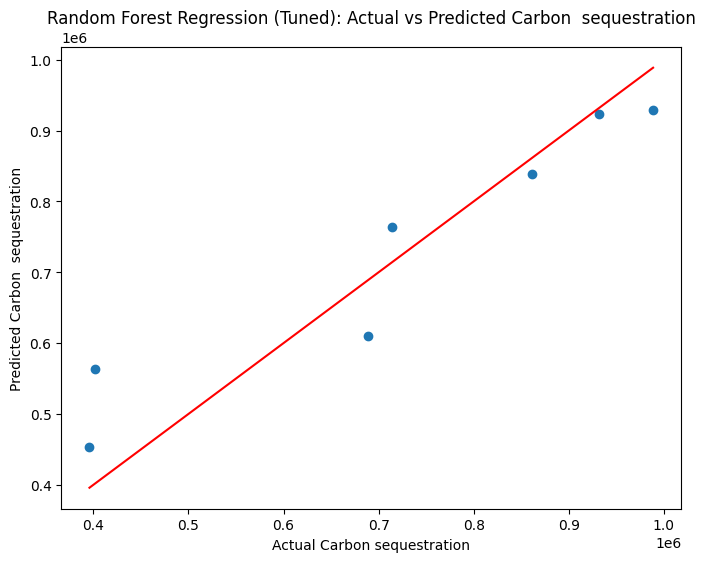

In [18]:
# Hyperparameter Tuning for Random Forest Regressor
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load dataset
data = pd.read_csv("/content/india_data_extracted (1).csv")

# Remove non-numeric column if present
data = data.drop(columns=["Area"])

# Target variable
y = data["total_emission"]

# Features
X = data[["Forest fires","Crop Residues","Pesticides Manufacturing"]]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20],   # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]  # Minimum number of samples required to be at a leaf node
}

# Create GridSearchCV object
# 'cv' specifies the number of folds for cross-validation
# 'scoring' specifies the metric to optimize (e.g., 'neg_mean_squared_error' for MSE)
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
print("Performing Grid Search for Hyperparameter Tuning...")
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = np.sqrt(-grid_search.best_score_) # Convert negative MSE back to RMSE

print(f"\nBest Parameters found: {best_params}")
print(f"Best RMSE from cross-validation: {best_score:.2f}")

# Evaluate the best model on the test set
best_rf_model = grid_search.best_estimator_
y_pred = best_rf_model.predict(X_test)

# Evaluation metrics for the best model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nTest Set Evaluation with Best Model:")
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

# Visualization of Actual vs Predicted values for the best model
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual Carbon sequestration")
plt.ylabel("Predicted Carbon  sequestration")
plt.title("Random Forest Regression (Tuned): Actual vs Predicted Carbon  sequestration")
plt.show()